# Preferential attachment (Barabasi-Albert model)

Function to run a step of (linear) preferential attachment

In [1]:
import networkx as nx
import numpy as np

def preferential_attachment(G, stubs):
  #add new node
  new_node = G.number_of_nodes()  # this gives the index of the node to add
  G.add_node(new_node)
  #pick attachment proportionally to the number of times a node appears in the stublist (i.e., its current degree)
  neighbor = np.random.choice(stubs)
  #add edge
  G.add_edge(new_node, neighbor)
  #update degrees ('state')
  G.nodes[new_node]['state'] = 1
  G.nodes[neighbor]['state'] += 1
  stubs.append(new_node)
  stubs.append(neighbor)
  return(G, stubs)

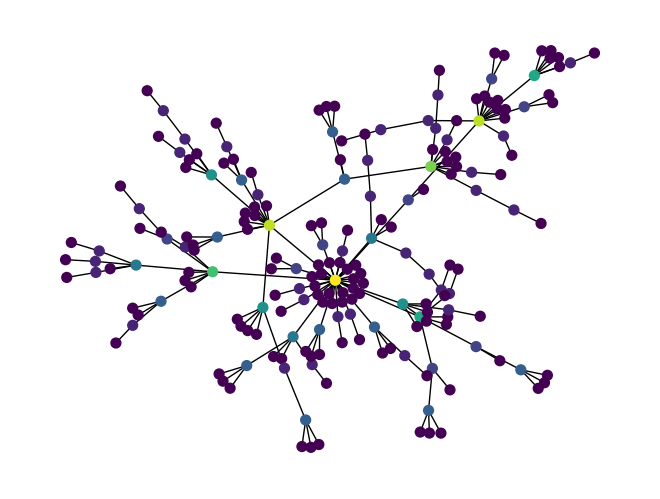

In [2]:
import networkx as nx
import numpy as np

G_ba = nx.Graph()
stubs_ba = []

#initial conditions
G_ba.add_node(0)
G_ba.add_node(1)
G_ba.add_edge(0,1)
stubs_ba.append(0)
stubs_ba.append(1)
G_ba.nodes[0]['state'] = 1
G_ba.nodes[1]['state'] = 1

for step in range(200):
  (G_ba, stubs_ba) = preferential_attachment(G_ba, stubs_ba)

from itertools import count
groups = set(nx.get_node_attributes(G_ba,'state').values())
mapping = dict(zip(sorted(groups),count()))
colors = [mapping[G_ba.nodes[n]['state']] for n in G_ba.nodes()]

nx.draw(G_ba, with_labels=False, node_size=50, pos=nx.fruchterman_reingold_layout(G_ba), node_color=colors)

In [3]:
g = G_ba
len(max(nx.connected_components(g), key=len)), nx.degree_centrality(g)



(202,
 {0: 0.06467661691542288,
  1: 0.1791044776119403,
  2: 0.029850746268656716,
  3: 0.03482587064676617,
  4: 0.02487562189054726,
  5: 0.014925373134328358,
  6: 0.01990049751243781,
  7: 0.009950248756218905,
  8: 0.03980099502487562,
  9: 0.004975124378109453,
  10: 0.01990049751243781,
  11: 0.004975124378109453,
  12: 0.004975124378109453,
  13: 0.029850746268656716,
  14: 0.004975124378109453,
  15: 0.014925373134328358,
  16: 0.014925373134328358,
  17: 0.06467661691542288,
  18: 0.004975124378109453,
  19: 0.004975124378109453,
  20: 0.01990049751243781,
  21: 0.009950248756218905,
  22: 0.02487562189054726,
  23: 0.004975124378109453,
  24: 0.004975124378109453,
  25: 0.05472636815920398,
  26: 0.014925373134328358,
  27: 0.004975124378109453,
  28: 0.004975124378109453,
  29: 0.004975124378109453,
  30: 0.009950248756218905,
  31: 0.03482587064676617,
  32: 0.009950248756218905,
  33: 0.01990049751243781,
  34: 0.004975124378109453,
  35: 0.01990049751243781,
  36: 0.009

In [4]:

import matplotlib.pyplot as plt
import networkx as nx

def plot_graphs_history(history, title):
    """
    Plot 10 graphs in a row showing the evolution of the network in the history.

    Args:
        history (list of tuples): Each tuple contains (removed_node, graph_snapshot).
        title (str): Title of the plot (e.g., "ER Graph History").
    """
    # Set up the figure with 10 subplots in a row
    fig, axes = plt.subplots(1, 10, figsize=(20, 5))
    
    # Select 10 evenly spaced steps from the history
    step_indices = [int(i * len(history) / 10) for i in range(10)]
    selected_steps = [history[idx] for idx in step_indices]

    for idx, (removed_node, g_snapshot) in enumerate(selected_steps):
        ax = axes[idx]
        ax.set_title(f"Step {idx + 1}\nRemoved {removed_node}", fontsize=8)
        

        pos = nx.spring_layout(g_snapshot)  # Use spring layout for better visualization
        nx.draw(
            g_snapshot, 
            pos=pos, 
            with_labels=False, 
            node_size=50, 
            ax=ax, 
            node_color="blue"
        )
        ax.axis("off")  # Turn off axis for better visuals

    # Set the overall title
    plt.suptitle(title, fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


# Plot the history for ER graph
# plot_graphs_history(history_er, "ER Graph History")

# Plot the history for BA graph
plot_graphs_history(history_ba, "BA Graph History")
# plot_lcc_vs_removed_semilog(history_er,history_ba)


NameError: name 'history_ba' is not defined

# Erdős-Rényi model

Fully random network where every pair of nodes is connected with probability p

In [10]:
#@title Random network generation { run: "auto" }

import networkx as nx
import numpy as np
import random

G_er = nx.Graph()

#density parameter
# p = 0.027 #@param {type:"slider", min:0, max:1, step:0.001}

for node in range(200):
  G_er.add_node(node)
  G_er.nodes[node]['state'] = 0
  for neighbor in range(G_er.number_of_nodes()-1):
    die = random.uniform(0, 1)
    if die<p: #create an edge
       G_er.add_edge(node,neighbor)
       G_er.nodes[node]['state'] += 1
       G_er.nodes[neighbor]['state'] += 1

from itertools import count
groups = set(nx.get_node_attributes(G_er,'state').values())
mapping = dict(zip(sorted(groups),count()))
colors = [mapping[G_er.nodes[n]['state']] for n in G_er.nodes()]

nx.draw(G_er, with_labels=False, node_size=50, pos=nx.fruchterman_reingold_layout(G_er), node_color=colors)

NameError: name 'p' is not defined

In [11]:
n = 200
print('p_perc =', 1/n, '("giant connected component" critical point || percolation threshold)')
print('p_conn =', np.log(n)/n, '("connectedness" critical point)')

p_perc = 0.005 ("giant connected component" critical point || percolation threshold)
p_conn = 0.02649158683274018 ("connectedness" critical point)


In [12]:


p = 2*n/(n*(n-1))
cost_edges = (G_er.number_of_nodes()*((G_er.number_of_nodes()-1)*p))/2 # p=1 you don't count same edge twice
cost_edges, G_er.number_of_edges(), p

(0.010050251256281407, 0, 0.010050251256281407)

In [ ]:
sum([G_er.nodes[node]['state'] for node in G_er.nodes])
(sum(1 for e in G_er.edges))/ ((G_er.number_of_nodes()*((G_er.number_of_nodes()-1)))/2)

0.026683417085427135

In [ ]:
G_er.number_of_edges()

183

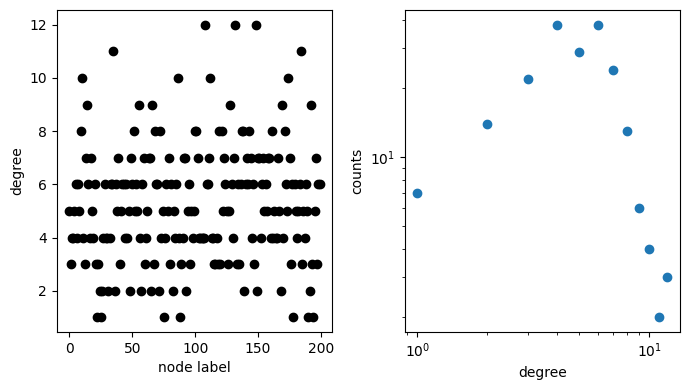

In [ ]:
import matplotlib.pyplot as plt

degree_freq = nx.degree_histogram(G_er)
degrees = range(len(degree_freq))

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(7, 4), tight_layout=True)
ax1.plot(G_er.nodes, nx.get_node_attributes(G_er,'state').values(), 'ko')
ax1.set(xlabel='node label', ylabel='degree')
ax2.loglog(degrees[1:], degree_freq[1:],'o')
ax2.set(xlabel='degree', ylabel='counts')
plt.show()

525

# Uniform attachment

Uniform, unbiased attachment

In [ ]:
#import networkx as nx
import numpy as np

def uniform_attachment(G):
  #pick attachment
  neighbor = np.random.choice(G.nodes)
  #add new node
  new_node = G.number_of_nodes()
  G.add_node(new_node)
  #pick attachment
  #add edge
  G.add_edge(new_node, neighbor)
  #update degrees
  G.nodes[new_node]['state'] = 1
  G.nodes[neighbor]['state'] += 1
  return(G)

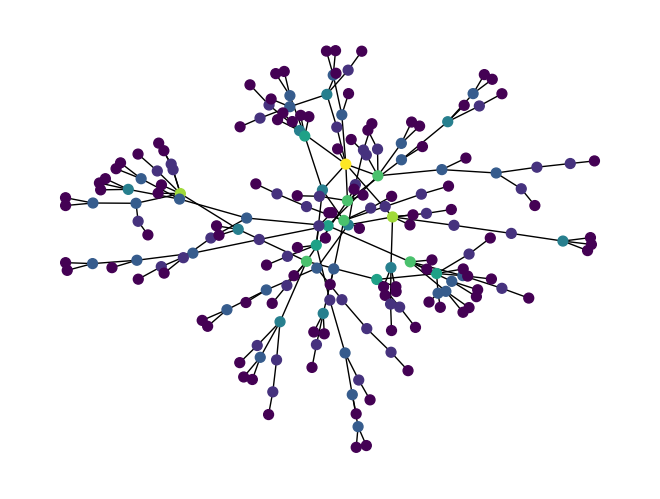

In [ ]:
import networkx as nx
import numpy as np

G_un = nx.Graph()

#initial conditions
G_un.add_node(0)
G_un.add_node(1)
G_un.add_edge(0,1)
G_un.nodes[0]['state'] = 1
G_un.nodes[1]['state'] = 1

for step in range(200):
  G_un = uniform_attachment(G_un)

from itertools import count
groups = set(nx.get_node_attributes(G_un,'state').values())
mapping = dict(zip(sorted(groups),count()))
colors = [mapping[G_un.nodes[n]['state']] for n in G_un.nodes()]

nx.draw(G_un, with_labels=False, node_size=50, pos=nx.spring_layout(G_un), node_color=colors)

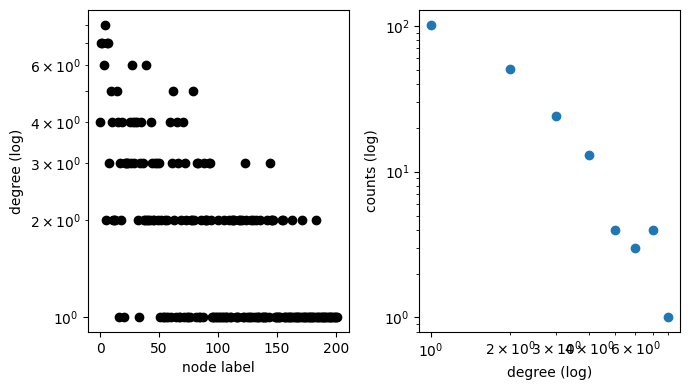

In [ ]:
import matplotlib.pyplot as plt

degree_freq = nx.degree_histogram(G_un)
degrees = range(len(degree_freq))

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(7, 4), tight_layout=True)
ax1.plot(G_un.nodes, nx.get_node_attributes(G_un,'state').values(), 'ko')
ax1.set(xlabel='node label', ylabel='degree (log)')
ax1.set(yscale='log')
ax2.loglog(degrees[1:], degree_freq[1:],'o')
ax2.set(xlabel='degree (log)', ylabel='counts (log)')
plt.show()

# Generalized preferential attachment

Generalized preferential attachment with tunable bias mu

In [3]:
import networkx as nx
import numpy as np
import random

def gen_preferential_attachment(G, chances, nu):
  #pick attachment
  neighbor = np.random.choice(G.nodes, 1, p = [x / sum(chances) for x in chances])[0]
  #add new node
  new_node = G.number_of_nodes()
  G.add_node(new_node)
  #add edge
  G.add_edge(new_node, neighbor)
  #update degrees
  chances.append(1)
  chances[neighbor] = (G.degree(neighbor))**-nu
  G.nodes[new_node]['state'] = 1
  G.nodes[neighbor]['state'] += 1
  return(G, chances)


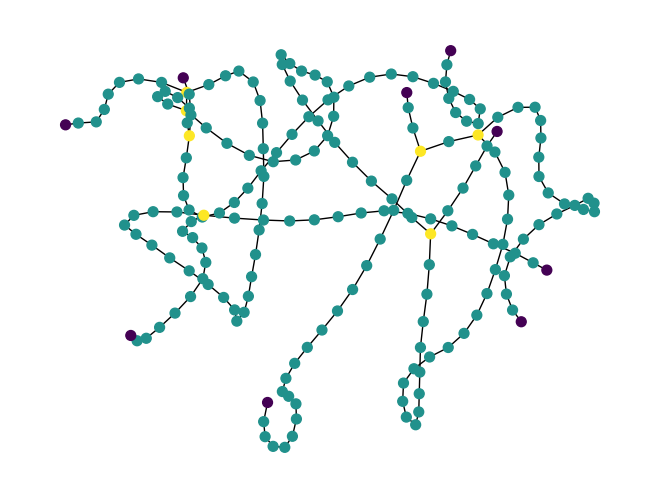

In [4]:
#@title Generalized preferential attachment { run: "auto" }
import networkx as nx
import numpy as np

G_pa = nx.Graph()
chances = []

#attachment kernel
nu = 10  #@param {type:"slider", min:-10, max:10, step:0.05}

#initial conditions
G_pa.add_node(0)
G_pa.add_node(1)
G_pa.add_edge(0,1)
chances.append(1)
chances.append(1)
G_pa.nodes[0]['state'] = 1
G_pa.nodes[1]['state'] = 1

for step in range(200):
  (G_pa, chances) = gen_preferential_attachment(G_pa, chances, nu)

from itertools import count
groups = set(nx.get_node_attributes(G_pa,'state').values())
mapping = dict(zip(sorted(groups),count()))
colors = [mapping[G_pa.nodes[n]['state']] for n in G_pa.nodes()]

nx.draw(G_pa, with_labels=False, node_size=50, pos=nx.fruchterman_reingold_layout(G_pa), node_color=colors)

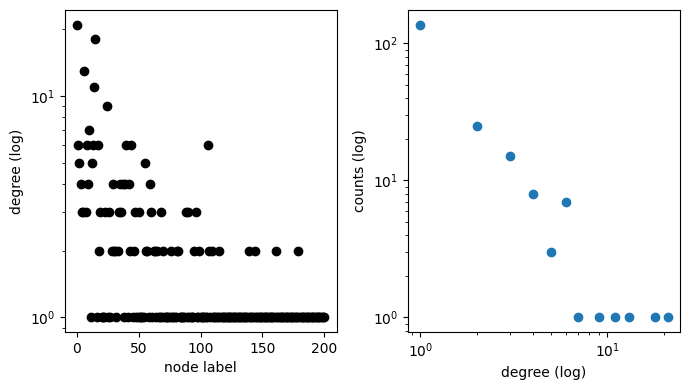

In [ ]:
import matplotlib.pyplot as plt

degree_freq = nx.degree_histogram(G_pa)
degrees = range(len(degree_freq))

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(7, 4), tight_layout=True)
ax1.plot(G_pa.nodes, nx.get_node_attributes(G_pa,'state').values(), 'ko')
ax1.set(xlabel='node label', ylabel='degree (log)')
ax1.set(yscale='log')
ax2.loglog(degrees[1:], degree_freq[1:],'o')
ax2.set(xlabel='degree (log)', ylabel='counts (log)')
plt.show()

## create 

In [5]:
import numpy as np

def internal_link_random_attachment(G, n):
  for i in range(n):
    #pick attachment
    node = np.random.choice(G.nodes)
    neighbor = np.random.choice(G.nodes)
    while neighbor == node:
        neighbor = np.random.choice(G.nodes)
    #add edge
    G.add_edge(node, neighbor)
    #update degrees
    G.nodes[node]['state'] = 1
    G.nodes[neighbor]['state'] += 1
  return(G)

In [6]:
# @title Generalized preferential attachment { run: "auto" }
import networkx as nx
import numpy as np


def create_G_pa(n=200, nu=-1, internal_links_per_node=0):
    G_pa = nx.Graph()
    chances = []

    # initial conditions
    G_pa.add_node(0)
    G_pa.add_node(1)
    G_pa.add_edge(0, 1)
    chances.append(1)
    chances.append(1)
    G_pa.nodes[0]["state"] = 1
    G_pa.nodes[1]["state"] = 1

    for step in range(n - 2):
        (G_pa, chances) = gen_preferential_attachment(G_pa, chances, nu)

        G_pa = internal_link_random_attachment(G_pa, internal_links_per_node)
    return G_pa


G_pa = create_G_pa(200, -2, internal_links_per_node=2)
len(G_pa.nodes)



200

## Shortest path  routing

In [8]:
import networkx as nx
import numpy as np
import random


def step_shortest_path(g, hops, failed = dict(), p = 0.5, step=1):
    nextg = g.copy()
    
    for node in (g.nodes):
        state = g.nodes[node]['state']
        next_state=[]

        # remove failed node
        # if len(state) > g.nodes[node]['capacity']: 
        #     nextg.remove_edges_from([(node,neighbor) for neighbor in g.neighbors(node)])            
        #     continue

        for packet in state:
            o, d, packet_id = packet
            hops[packet].append(node)
            if d == node:
                # Packet reaches its destination
                continue
            elif len(next_state) >= g.nodes[node]['capacity']:  #failed packets                
                failed[node].append(packet)    # to retry to failed node
            else:
                next_state.append(packet)
            
        
        while  len(next_state) > 0:
            packet = next_state.pop()
            o, d, packet_id = packet
            # Check if a path exists between the source and target
            if nx.has_path(g, node, d):
                path = nx.shortest_path(g, source=node, target=d, weight="weight")
                neighbor = path[1]  # Get the next node in the path
                nextg.nodes[neighbor]['state'].append(packet)
            

        # generate a packet 
        die = random.uniform(0, 1)
        if die<p:
            dest = np.random.choice(list(g.nodes))
            packet = (node, dest, step)
            next_state.append(packet)
            hops[packet] = list([node])


        retry = failed[node]
        for (packet) in retry:##retry failed nodes packets, retry adds delay, recycle packet
            last_neighbor = hops[packet].pop()  #packet goes back to neighbor
            nextg.nodes[last_neighbor]['state'].append(packet)
            failed[node].remove(packet)

        nextg.nodes[node]['state'] = next_state   
    return nextg, hops, failed
    


def run_shortest_path(g, capacity=2*np.ones(200), p=0.5):
    for node in g.nodes:
        g.nodes[node]['state'] = list()
        g.nodes[node]['capacity'] = capacity[node]

    history=[]
    failed = dict([(node,list()) for node in g.nodes])
    hops = dict()

    for step in range(200):
        g, hops, failed = step_shortest_path(g, hops, failed, p, step)
        history.append(( g))
       
    return history, hops, failed




# Robustness

## Measuring robustness functions

In [105]:
import networkx as nx
import numpy as np
import random

def get_degree_moment(g, moment=1):
    degree_freq = nx.degree_histogram(g)
    degrees = range(len(degree_freq))
    k = sum([( (d**moment)*f) for (d,f) in zip(degrees,degree_freq)])/sum(degree_freq)
    return k

def get_critical(g):

    k = get_degree_moment(g, 1)
    k_moment_2nd = get_degree_moment(g, 2)
    f_c = 1-1/(k_moment_2nd/k - 1)
    return f_c


def get_fraction_LCC(g):
    from math import e, exp
    k = get_degree_moment(g,1)
    r = 200 - g.number_of_nodes()
    f_r = r/200
    S = 1 - f_r
    f_s = 1 - exp(-k*S)
    lcc =  len(max(nx.connected_components(g), key=len))
    return (f_r, f_s, lcc)

# get fraction removed, LCC
def remove_nodes_random(g):

    history = []
    fractions = []
    random_nodes = random.sample(list(g.nodes), g.number_of_nodes())
    for node in random_nodes:
        g.remove_node(node)
        if g.number_of_nodes() == 0:
            continue
        (f_r, f_s, lcc) = get_fraction_LCC(g)
        fractions.append((f_r, f_s, lcc))
        history.append((g.copy()))
    return fractions, history
    


### Plot and draw

In [139]:
# plot 
def plot_LCC_vs_fraction_removed(fractions, f_c, k, nu=1, n=1):
    import matplotlib.pyplot as plt

  
    
    fig, (ax1, ax2) = plt.subplots(1,2, figsize=(7, 4), tight_layout=True)
    f_r = [f_r for (f_r, f_s, lcc) in fractions]
    f_s = [f_s for (f_r, f_s, lcc) in fractions]
    lcc = [lcc for (f_r, f_s, lcc) in fractions]

    ax1.plot(f_r[1:], lcc[1:], 'ko')
    ax1.set(xlabel='f_r', ylabel='LCC')
    ax1.legend()
    # ax2.loglog(f_r[1:], f_s[1:],'o')
    # ax2.set(xlabel='f_r', ylabel='f(S)')
    ax1.vlines(f_c, ymin=0, ymax=max(lcc), color="blue", linestyles="dashed", label=f"Critical Point (f_c={f_c:.2f})")
    # ax2.vlines(f_c, ymin=0, ymax=max(lcc), color="blue", linestyles="dashed", label="critical point")

    # ax2.plot(nodes, average_flows_per_node, 'ko')
    # ax2.set(xlabel='node label', ylabel='flow avg (log)')
    # ax2.set(yscale='log')


    fig.suptitle(f"⟨k⟩ = {k:.2f}\n$f_c$ = {f_c:.2f}\n$\\nu={nu}$\n$n={n}$", fontsize=14)

     
    return fig, (ax1, ax2)

# plot the critical fraction
def plot_robustness_f_c(robustness_2tuples, label='robustness_for_aging', xlabel='$\\nu$'):
  fig, ax = plt.subplots(figsize=(8,6), tight_layout=True)
  # ax.plot([D for (D, cost) in cost_and_delay1], [cost for (D, cost) in cost_and_delay1], 'o', label='uniform heuristic')
  # ax.set(xlabel='D', ylabel='cost')
  # ax.set(yscale='log')
  ax.plot([nu for (f_c, nu) in robustness_2tuples], 
          [f_c for (f_c, nu) in robustness_2tuples], 
          'o', label=label)
  ax.set(xlabel=xlabel, ylabel='$f_c$')
  ax.set(yscale='log')
  
  ax.legend();



  ax.legend();
def draw_one(g, node_values, D, s, title="Failures", ax=None):
    import matplotlib.pyplot as plt
    import matplotlib.cm as cm
    import networkx as nx
    from itertools import count

    # Get unique groups and map them to colors
    groups = sorted(set(node_values))
    mapping = dict(zip(groups, count()))
    colors = [mapping[n] for n in node_values]

    # Define a colormap
    colormap = cm.get_cmap("viridis", len(groups))  # Use a colormap with distinct colors
    color_list = [colormap(mapping[group]) for group in groups]

    # Draw the graph
    pos = nx.fruchterman_reingold_layout(g)
    nx.draw(
        g,
        with_labels=False,
        node_size=50,
        pos=pos,
        node_color=[colormap(mapping[n]) for n in node_values],
    )

    # Add a legend
    handles = [
        plt.Line2D(
            [], [], marker="o", color=color_list[i], linestyle="", label=f"{group}"
        )
        for i, group in enumerate(groups)
    ]
    if ax==None:
       ax = plt
    ax.legend(
        handles=handles,
        title=title,
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
        borderaxespad=0.0,
    )

    # Add title for the graph plot
    ax.suptitle(f"D = {D:.2f}\n{s}", fontsize=12)
    ax.show()


## Cascading failure

C:\Users\Trevor.Webster\AppData\Local\Temp\ipykernel_26120\2795553810.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap("viridis", len(groups))  # Use a colormap with distinct colors


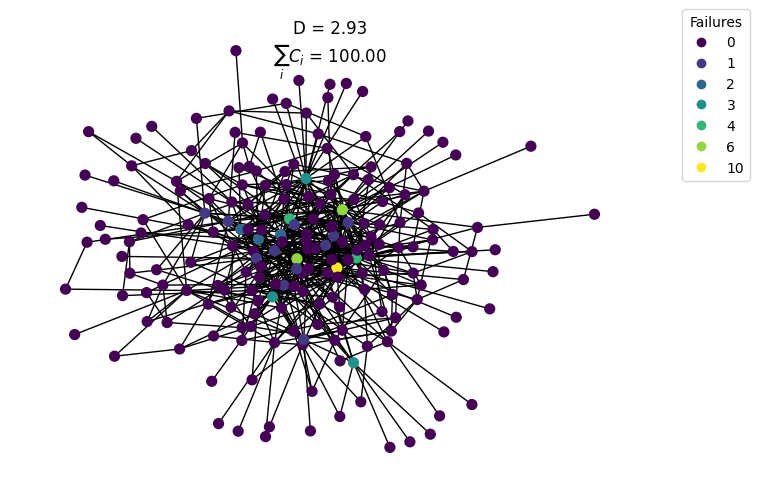

In [ ]:
g = G_pa.copy()
history, hops, failed = run_shortest_path(g, p=0.5)
g = history[-1]
draw_one(g, [len(failed[node]) for node in g.nodes], D, 100)


## Robustness for internal links

adding links did not improve average delay since no small world phenomenon was found nor is it apparent that adding links makes the shortest path more optimal than the hub
as most nodes are low degree and have little betweenness

as failed packets are recycled, an inefficient topology will reproduce failures

In [109]:
def evaluate_robustness(g):
    f_c = get_critical(g)
    k = get_degree_moment(g)
    fractions, _ = remove_nodes_random(g.copy())
    return fractions, f_c, k


C:\Users\Trevor.Webster\AppData\Local\Temp\ipykernel_5532\2790393431.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()
C:\Users\Trevor.Webster\AppData\Local\Temp\ipykernel_5532\2790393431.py:59: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap("viridis", len(groups))  # Use a colormap with distinct colors


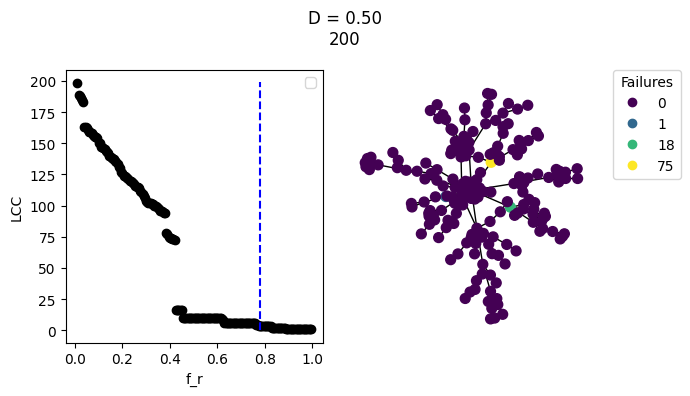

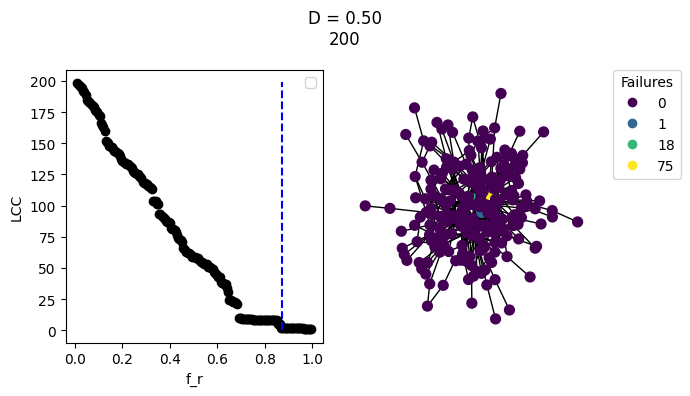

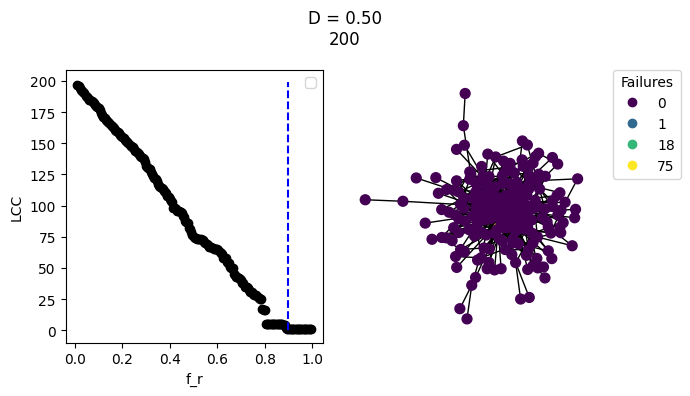

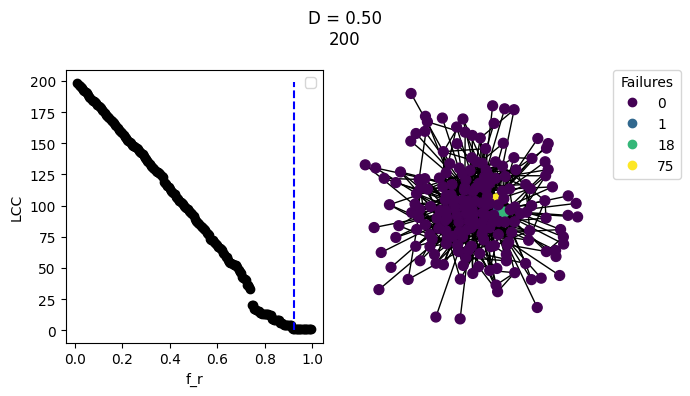

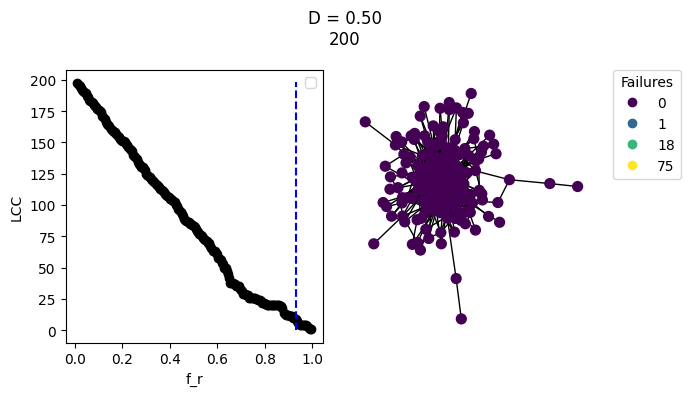

In [141]:
robustness_for_internal_links=[]

for n in  np.arange(0,5,1):
    g = create_G_pa(200, -1, n)    

    fractions, f_c, k = evaluate_robustness(g)
    plot_LCC_vs_fraction_removed( fractions, f_c, k)  
    draw_one(g, [len(failed[node]) for node in g.nodes], D, cost)
    robustness_for_internal_links.append((f_c, n)) 


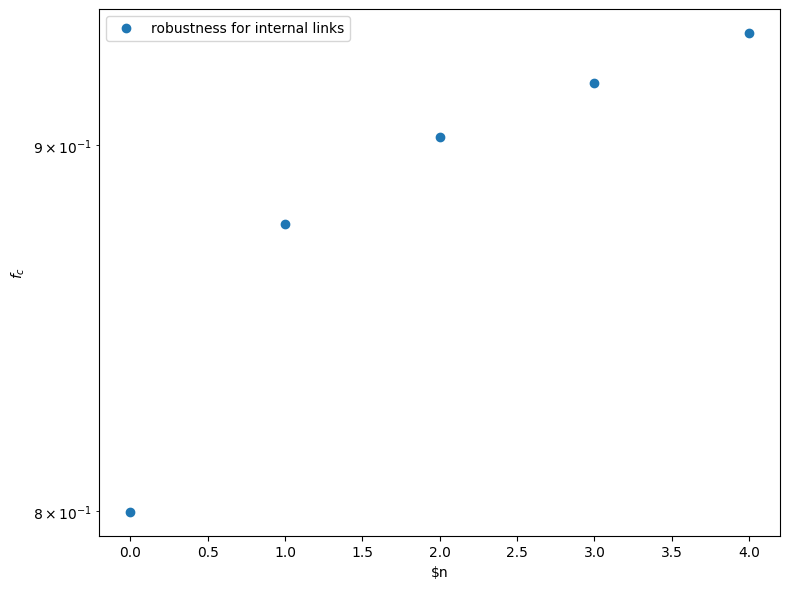

In [ ]:
plot_robustness_f_c(robustness_for_internal_links, "robustness for internal links", "$n$")

## Robustness for aging 

Preferentially attaching to older or newer

k vs f_c
nu vs f_c

In [128]:
robustness_for_aging=[]

for nu in np.arange(-1,2,0.5):
    n = 1   # internal links
    g = create_G_pa(200, nu, n)    
    fractions, f_c, k = evaluate_robustness(g)
    robustness_for_aging.append((f_c, nu))
    # plot_LCC_vs_fraction_removed( fractions, f_c, k, nu, n)   

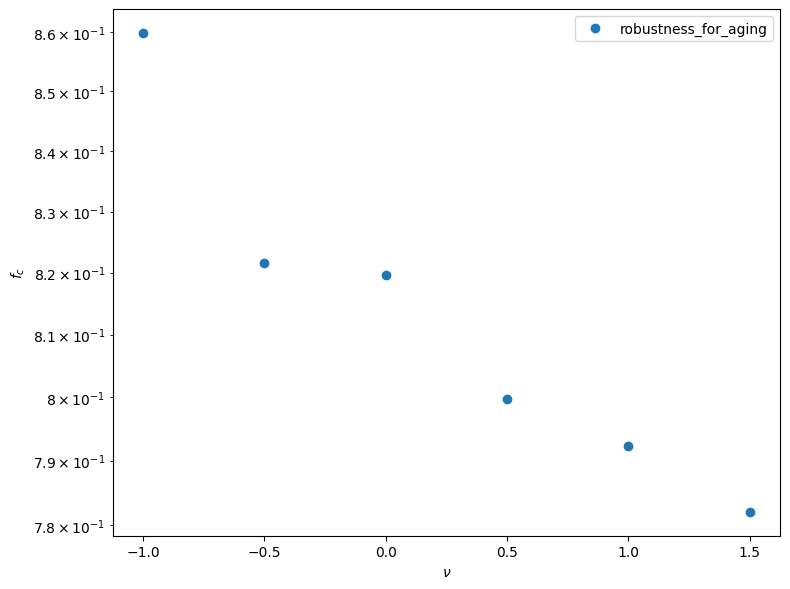

In [129]:
plot_robustness_f_c(robustness_for_aging)

# Capacity assignment problem

D vs C

## Delay and flow


In [87]:
## Delay and flow

## Delay and flow
def get_flows(history):    
    flows_history = []
    for g in history:    
        nodes = list(g.nodes)
        flows_at_step = [len(g.nodes[node]['state']) for node in g.nodes]
        flows_history.append(flows_at_step)

    flows_history= np.array(flows_history)
    average_flows_per_node = np.mean(flows_history, axis=0)
    return average_flows_per_node

#440 Routing in Data Networks Chap. 5 
# #The flow on each link (i. j) is denoted Fij and is expressed in the same units as capacity. , so we can express the average delay constraint as (5.35)
# Respects degree in that flows to node are characteristic of its importance, and the estimate is qualitative
def get_delay_5_35(average_flows_per_node, capacity=[2 for node in range(200)]):    
    gamma = sum(average_flows_per_node)
    capacity = np.array(capacity)
    # D = (1/gamma) * sum([F_i/(C_i-F_i) for (F_i, C_i) in zip(average_flows_per_node, capacity)]) # (5.30)
    D = (1/gamma) * sum([F_i/C_i for (F_i, C_i) in zip(average_flows_per_node, capacity)]) #(5.31) A computational study [Vas79] has shown that it typically makes little difference whether the cost function of Eqs. (5.29) and (5.30) or that of Eq. (5.31) is used for routing optimization

    return D


def reassign_capacity(average_flows_per_node, capacity):
    p_capacity = average_flows_per_node / sum(average_flows_per_node)
    reassigned_capacity = (sum(capacity)) * p_capacity
    return reassigned_capacity



In [29]:
# capacity=[2 for node in range(200)]
# history, hops, failed = run_shortest_path(g, capacity, p=0.5)
average_flows_per_node = get_flows(history)
get_delay_5_35(average_flows_per_node)


0.5

In [ ]:

def evaluate_cost(average_flows_per_node, capacity):
    D = get_delay_5_35(average_flows_per_node, capacity)
    cost = sum(capacity)
    return D, cost


In [54]:
import numpy as np
import matplotlib.pyplot as plt

#get initial data to assign capacities next 
g = G_pa.copy()
history, hops, failed = run_shortest_path(g, capacity=[2 for node in g.nodes], p=0.5) 
average_flows_per_node = get_flows(history)
cost_and_delay1 = []
cost_and_delay2 = []


In [56]:

# instead of running long simulation use cost estimation on statistics
for C in range(4,0,-1) :
    capacity = [C for node in g.nodes]
    (D, cost) = evaluate_cost(average_flows_per_node, capacity) 
    cost_and_delay1.append((D, cost))
    capacity = reassign_capacity(average_flows_per_node, capacity)
    (D, cost) = evaluate_cost(average_flows_per_node, capacity) 
    cost_and_delay2.append((D, cost))



In [72]:
cost_and_delay1, cost_and_delay2

([(0.25, 800), (0.33333333333333354, 600), (0.5, 400), (1.0, 200)],
 [(0.25, 800.0000000000002),
  (0.33333333333333254, 599.9999999999978),
  (0.5, 400.0000000000001),
  (1.0, 200.00000000000006)])

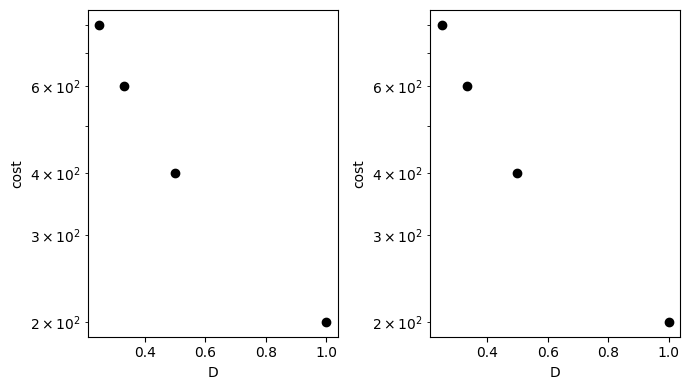

In [61]:

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(7, 4), tight_layout=True)
ax1.plot([D for (D, cost) in cost_and_delay1], [cost for (D, cost) in cost_and_delay1], 'ko')
ax1.set(xlabel='D', ylabel='cost')
ax1.set(yscale='log')

ax2.plot([D for (D, cost) in cost_and_delay2], [cost for (D, cost) in cost_and_delay2], 'ko')
ax2.set(xlabel='D', ylabel='cost')
ax2.set(yscale='log')
plt.show()

In [62]:
capacity=[2 for node in g.nodes]
#random sample k according to lowest use
#reduce capacity to 1
node_and_flow = sorted([(flow,node) for (node, flow) in zip(range(len(g.nodes)), average_flows_per_node)] )
cost_and_delay3 = []
for (flow,node) in node_and_flow:
    capacity[node] = max(1, capacity[node]-1)
    (D, cost) = evaluate_cost(average_flows_per_node, capacity) 
    cost_and_delay3.append((D, cost))




[None]

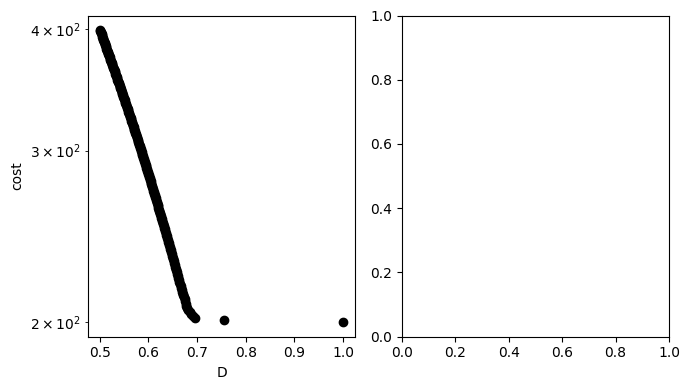

In [63]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(7, 4), tight_layout=True)
ax1.plot([D for (D, cost) in cost_and_delay3], [cost for (D, cost) in cost_and_delay3], 'ko')
ax1.set(xlabel='D', ylabel='cost')
ax1.set(yscale='log')

In [117]:
def plot_cost(S,I,R):
  fig, ax = plt.subplots(figsize=(8,6), tight_layout=True)
  # ax.plot([D for (D, cost) in cost_and_delay1], [cost for (D, cost) in cost_and_delay1], 'o', label='uniform heuristic')
  # ax.set(xlabel='D', ylabel='cost')
  # ax.set(yscale='log')
  ax.plot([D for (D, cost) in cost_and_delay2], [cost for (D, cost) in cost_and_delay2], 'o', label='proportion to flow heuristic')
  ax.set(xlabel='D', ylabel='cost')
  ax.set(yscale='log')
  ax.plot([D for (D, cost) in cost_and_delay3], [cost for (D, cost) in cost_and_delay3], 'ko', label='lowest hanging fruit heuristic')
  ax.set(xlabel='D', ylabel='cost')
  ax.set(yscale='log')


  ax.legend();

The cost is minimized following a power law until a delay of 0.7

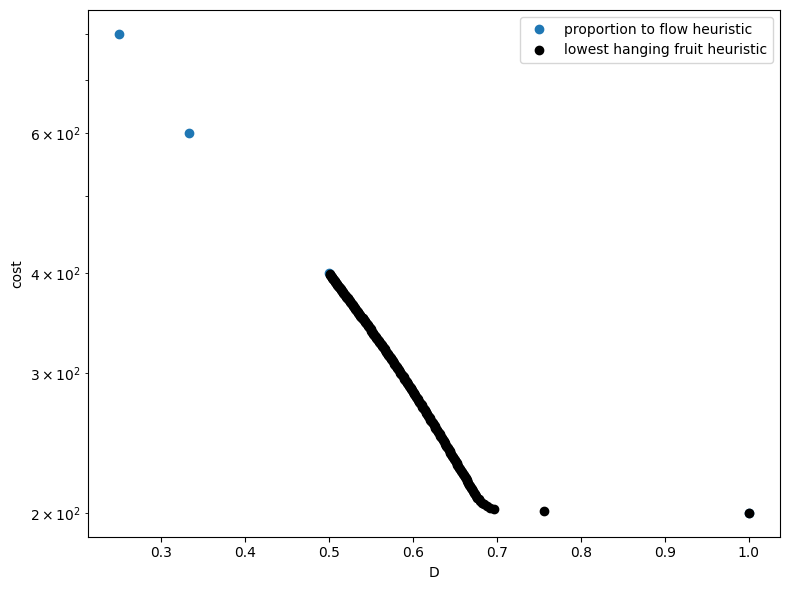

In [118]:
plot_cost(cost_and_delay1, cost_and_delay2, cost_and_delay3)

## Resilience and adaptive routing

### hot potato routing

deflects to neighbors minimizes cost to one node not to neighbors

In [97]:
import networkx as nx
import numpy as np
import random


def step_hot_potato(g, hops, failed = dict(), p = 0.5, step=1):
    nextg = g.copy()
    
    for node in (g.nodes):
        state = g.nodes[node]['state']
        next_state=[]

        # remove failed node
        # if len(state) > g.nodes[node]['capacity']: 
        #     nextg.remove_edges_from([(node,neighbor) for neighbor in g.neighbors(node)])            
        #     continue

        for packet in state:
            o, d, packet_id = packet
            hops[packet].append(node)
            if d == node:
                # Packet reaches its destination
                continue
            elif len(next_state) >= g.nodes[node]['capacity']:  #failed packets                
                failed[node].append(packet)    # to retry to failed node
            else:
                next_state.append(packet)
            
        
        neighbors= list(g.neighbors(node)) # , there will be no queueing,
        while len(next_state) > 0:
            packet = next_state.pop()
            neighbor = np.random.choice(neighbors)
            nextg.nodes[neighbor]['state'].append(packet)

            

        # generate a packet 
        die = random.uniform(0, 1)
        if die<p:
            dest = np.random.choice(list(g.nodes))
            packet = (node, dest, step)
            next_state.append(packet)
            hops[packet] = list([node])


        retry = failed[node]
        for (packet) in retry:##retry failed nodes packets, retry adds delay, recycle packet
            last_neighbor = hops[packet].pop()  #packet goes back to neighbor
            nextg.nodes[last_neighbor]['state'].append(packet)
            failed[node].remove(packet)

        nextg.nodes[node]['state'] = next_state   
    return nextg, hops, failed
    


def run_hot_potato(g, capacity=2*np.ones(200), p=0.5):
    for node in g.nodes:
        g.nodes[node]['state'] = list()
        g.nodes[node]['capacity'] = capacity[node]

    history=[]
    failed = dict([(node,list()) for node in g.nodes])
    hops = dict()

    for step in range(200):
        g, hops, failed = step_hot_potato(g, hops, failed, p, step)
        history.append(( g))
       
    return history, hops, failed




C:\Users\Trevor.Webster\AppData\Local\Temp\ipykernel_5532\534052939.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap("viridis", len(groups))  # Use a colormap with distinct colors


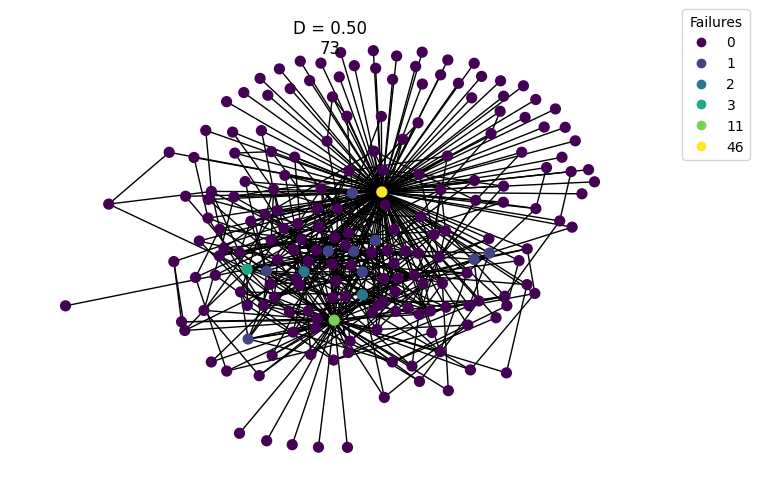

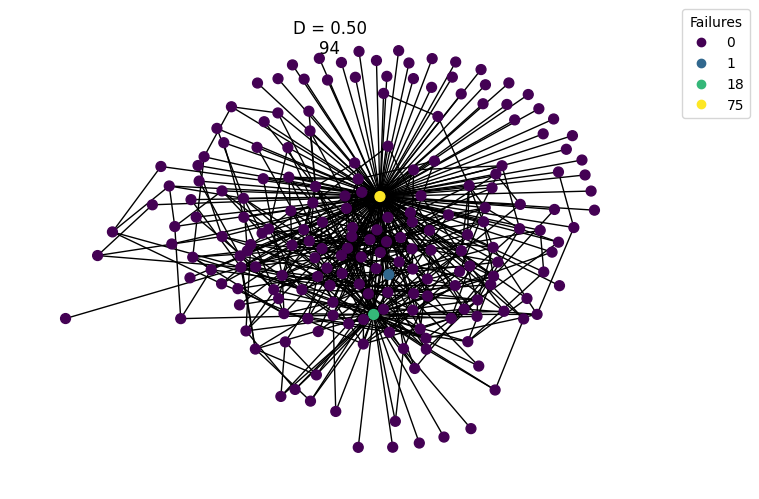

In [ ]:
g = G_pa.copy()
# set capacity
capacity=[2 for node in range(200)]

# run 
history, hops, failed = run_hot_potato(g, capacity, p=0.5)

# get delay
average_flows_per_node = get_flows(history)
D=get_delay_5_35(average_flows_per_node, capacity)

g = history[-1]
# get size of cascade
s = sum([len(failed[node]) for node in failed.keys()])
draw_one(g, [len(failed[node]) for node in g.nodes], D, s)

# run 
history, hops, failed = run_shortest_path(g, capacity, p=0.5)

# get delay
average_flows_per_node = get_flows(history)
D=get_delay_5_35(average_flows_per_node, capacity)

g = history[-1]
# get size of cascade
s = sum([len(failed[node]) for node in failed.keys()])
draw_one(g, [len(failed[node]) for node in g.nodes], D, s)

